Задание
Для набора данных своего варианта из практической работы № 3 
разработайте несколько kNN-классификаторов, используя различное 
соотношение числа объектов в обучающей и тестовой выборках, раз
личные способы оценки расстояния между объектами и варианты голосования (невзвешенное и взвешенное), для процедуры перекрестной 
проверки рассмотрите различные значения ее кратности.  
Сравните качество обученных классификторов и по результатам 
обучения трех лучших kNN-классификаторов подготовьте отчет, в который включите табличные и 4 – 6 графических обзоров о результатах 
моделирования.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
import requests
from io import StringIO

# Стиль графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Исправленная функция загрузки данных
def load_and_prepare_data():
    # Загрузка данных
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/echocardiogram/echocardiogram.data"
    
    # Загрузка данных в текстовом виде
    response = requests.get(url)
    raw_data = response.text
    
    # Обработка данных вручную
    lines = raw_data.strip().split('\n')
    parsed_data = []
    
    for i, line in enumerate(lines):
        # Делим по запятым и удаляем пустоту
        values = [x.strip() for x in line.split(',') if x.strip()]
        parsed_data.append(values)
    
    # Создаем DataFrame
    columns = ['survival', 'still-alive', 'age-at-heart-attack', 'pericardial-effusion',
               'fractional-shortening', 'epss', 'lvdd', 'wall-motion-score',
               'wall-motion-index', 'mult', 'name', 'group', 'alive-at-1']
    
    # Создаем DataFrame с максимальным количеством столбцов
    max_cols = max(len(row) for row in parsed_data)
    if max_cols > len(columns):
        columns = columns + [f'extra_{i}' for i in range(max_cols - len(columns))]
    
    data = pd.DataFrame(parsed_data, columns=columns[:max_cols])
    
    # Данные в числовом формате
    for col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    
    # Пропущенные значения
    print("Пропущенные значения по столбцам:")
    print(data.isnull().sum())
    
    columns_to_drop = ['name', 'group']
    existing_columns_to_drop = [col for col in columns_to_drop if col in data.columns]
    if existing_columns_to_drop:
        data = data.drop(existing_columns_to_drop, axis=1)
    
    # Также удалим дополнительные столбцы, если они есть
    extra_columns = [col for col in data.columns if col.startswith('extra_')]
    if extra_columns:
        data = data.drop(extra_columns, axis=1)
    
    print(f"Столбцы после удаления: {list(data.columns)}")
    
    # Обработка пропущенных значений
    print(f"До удаления пропусков: {len(data)} строк")
    data_clean = data.dropna()
    print(f"После удаления пропусков: {len(data_clean)} строк")
    
    # Используем 'still-alive' как целевую переменную
    target_column = 'still-alive'
    
    print(f"Используем '{target_column}' как целевую переменную")
    
    X = data_clean.drop(target_column, axis=1)
    y = data_clean[target_column]
    
    print(f"Размеры после подготовки: X={X.shape}, y={y.shape}")
    print("Распределение целевой переменной:")
    print(y.value_counts())
    
    return X, y


In [14]:
# Функция для оценки модели
def evaluate_knn_model(model, X_train, X_test, y_train, y_test, cv_folds=5):
    # Обучение модели
    model.fit(X_train, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring='accuracy')
    
    return {
        'model': model,
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'cv_scores': cv_scores,
        'classification_report': classification_report(y_test, y_pred, output_dict=True),
        'X_test': X_test,  # Сохраняем тестовые данные
        'y_test': y_test   # Сохраняем тестовые метки
    }

In [15]:

# Функция для построения графиков результатов
def plot_knn_results(results, model_name, features):
    """Построение графиков для kNN модели"""
    # Используем сохраненные тестовые данные
    X_test = results['X_test']
    y_test = results['y_test']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Результаты kNN модели: {model_name}', fontsize=16)
    
    # 1. Матрица ошибок
    cm = confusion_matrix(y_test, results['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
    axes[0,0].set_title('Матрица ошибок')
    axes[0,0].set_xlabel('Предсказанные')
    axes[0,0].set_ylabel('Фактические')
    
    # 2. Параметры модели
    if hasattr(results['model'], 'best_params_'):
        best_k = results['model'].best_params_.get('kneighborsclassifier__n_neighbors', 'N/A')
        metric = results['model'].best_params_.get('kneighborsclassifier__metric', 'N/A')
        weights = results['model'].best_params_.get('kneighborsclassifier__weights', 'N/A')
        axes[0,1].text(0.5, 0.5, f'Лучший k: {best_k}\nМетрика: {metric}\nВеса: {weights}',
                      ha='center', va='center', transform=axes[0,1].transAxes, fontsize=12)
    else:
        if hasattr(results['model'], 'steps'):
            # Для pipeline
            knn_step = results['model'].steps[-1][1]
            k = knn_step.n_neighbors
            metric = knn_step.metric
            weights = knn_step.weights
        else:
            # Для простого классификатора
            k = results['model'].n_neighbors
            metric = results['model'].metric
            weights = results['model'].weights
        
        axes[0,1].text(0.5, 0.5, f'k: {k}\nМетрика: {metric}\nВеса: {weights}',
                      ha='center', va='center', transform=axes[0,1].transAxes, fontsize=12)
    
    axes[0,1].set_title('Параметры модели')
    axes[0,1].axis('off')
    
    # 3. ROC-кривая (если доступны вероятности)
    if results['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
        roc_auc = auc(fpr, tpr)
        
        axes[0,2].plot(fpr, tpr, color='darkorange', lw=2,
                      label=f'ROC кривая (AUC = {roc_auc:.2f})')
        axes[0,2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[0,2].set_xlim([0.0, 1.0])
        axes[0,2].set_ylim([0.0, 1.05])
        axes[0,2].set_xlabel('False Positive Rate')
        axes[0,2].set_ylabel('True Positive Rate')
        axes[0,2].set_title('ROC-кривая')
        axes[0,2].legend(loc="lower right")
    else:
        axes[0,2].text(0.5, 0.5, 'ROC-кривая\nнедоступна',
                      ha='center', va='center', transform=axes[0,2].transAxes)
        axes[0,2].set_title('ROC-кривая')
    
    # 4. Сравнение точности при разных k
    k_values = [3, 5, 7, 9, 11]
    accuracy_scores = []
    
    for k in k_values:
        temp_model = KNeighborsClassifier(n_neighbors=k)
        
        # Используем те же данные, что и для исходной модели
        if hasattr(results['model'], 'steps'):
            # Для pipeline используем scaler из pipeline
            scaler = results['model'].steps[0][1]
            X_train_scaled = scaler.transform(results['model'].steps[1][1]._fit_X)
            X_test_scaled = scaler.transform(X_test)
            temp_model.fit(X_train_scaled, results['model'].steps[1][1]._y)
            accuracy_scores.append(accuracy_score(y_test, temp_model.predict(X_test_scaled)))
        else:
            # Для простого классификатора
            temp_model.fit(results['model']._fit_X, results['model']._y)
            accuracy_scores.append(accuracy_score(y_test, temp_model.predict(X_test)))
    
    axes[1,0].plot(k_values, accuracy_scores, 'o-')
    axes[1,0].set_xlabel('Количество соседей (k)')
    axes[1,0].set_ylabel('Точность')
    axes[1,0].set_title('Точность при разных k')
    axes[1,0].grid(True)
    
    # 5. Кросс-валидационные оценки
    if 'cv_scores' in results:
        cv_scores = results['cv_scores']
        axes[1,1].bar(range(1, len(cv_scores)+1), cv_scores, color='lightblue', alpha=0.7)
        axes[1,1].axhline(y=results['cv_mean'], color='red', linestyle='--', label=f'Среднее: {results["cv_mean"]:.3f}')
        axes[1,1].set_xlabel('Фолд кросс-валидации')
        axes[1,1].set_ylabel('Точность')
        axes[1,1].set_title('Результаты кросс-валидации')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
    
    # 6. Сравнение метрик классификации
    report = results['classification_report']
    metrics = ['precision', 'recall', 'f1-score']
    classes = [str(cls) for cls in report.keys() if cls not in ['accuracy', 'macro avg', 'weighted avg']]
    
    metric_data = []
    for cls in classes:
        for metric in metrics:
            if metric in report[cls]:
                metric_data.append({
                    'Класс': cls,
                    'Метрика': metric,
                    'Значение': report[cls][metric]
                })
    
    if metric_data:
        metric_df = pd.DataFrame(metric_data)
        sns.barplot(data=metric_df, x='Метрика', y='Значение', hue='Класс', ax=axes[1,2])
        axes[1,2].set_title('Метрики классификации по классам')
        axes[1,2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    return fig


In [22]:
# Основной эксперимент
def run_knn_experiment():
    # Загрузка данных
    X, y = load_and_prepare_data()
    
    # Различные конфигурации для экспериментов
    test_sizes = [0.2, 0.3, 0.4]  # Размеры тестовой выборки
    metrics = ['euclidean', 'manhattan', 'chebyshev']  # Метрики расстояния
    weights_options = ['uniform', 'distance']  # Типы голосования
    cv_folds_options = [5, 10]  # Кратности перекрестной проверки
    n_neighbors_range = [3, 5, 7, 9, 11]  # Количество соседей
    
    results = []
    
    # Счетчик для уникальных идентификаторов моделей
    model_counter = 0
    
    # Эксперимент 1: Различные соотношения train/test
    print("\n1. Различные соотношения train/test:")
    for test_size in test_sizes:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        
        # Масштабирование признаков
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Базовый kNN
        knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform')
        
        result = evaluate_knn_model(knn, X_train_scaled, X_test_scaled, y_train, y_test)
        model_counter += 1
        results.append({
            'model_id': model_counter,
            'test_size': test_size,
            'metric': 'euclidean',
            'weights': 'uniform',
            'cv_folds': 5,
            'n_neighbors': 5,
            'accuracy': result['accuracy'],
            'cv_mean': result['cv_mean'],
            'cv_std': result['cv_std'],
            'model': knn,
            'full_result': result,
            'config': f'test_size={test_size}, metric=euclidean, weights=uniform, n_neighbors=5'
        })
        
        print(f"  test_size={test_size}: Точность = {result['accuracy']:.4f}")
    
    # Эксперимент 2: Различные метрики расстояния
    print("\n2. Различные метрики расстояния:")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for metric in metrics:
        knn = KNeighborsClassifier(n_neighbors=5, metric=metric, weights='uniform')
        
        result = evaluate_knn_model(knn, X_train_scaled, X_test_scaled, y_train, y_test)
        model_counter += 1
        results.append({
            'model_id': model_counter,
            'test_size': 0.2,
            'metric': metric,
            'weights': 'uniform',
            'cv_folds': 5,
            'n_neighbors': 5,
            'accuracy': result['accuracy'],
            'cv_mean': result['cv_mean'],
            'cv_std': result['cv_std'],
            'model': knn,
            'full_result': result,
            'config': f'test_size=0.2, metric={metric}, weights=uniform, n_neighbors=5'
        })
        
        print(f"  metric={metric}: Точность = {result['accuracy']:.4f}")
    
    # Эксперимент 3: Взвешенное vs невзвешенное голосование
    print("\n3. Взвешенное vs невзвешенное голосование:")
    for weights in weights_options:
        knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights=weights)
        
        result = evaluate_knn_model(knn, X_train_scaled, X_test_scaled, y_train, y_test)
        model_counter += 1
        results.append({
            'model_id': model_counter,
            'test_size': 0.2,
            'metric': 'euclidean',
            'weights': weights,
            'cv_folds': 5,
            'n_neighbors': 5,
            'accuracy': result['accuracy'],
            'cv_mean': result['cv_mean'],
            'cv_std': result['cv_std'],
            'model': knn,
            'full_result': result,
            'config': f'test_size=0.2, metric=euclidean, weights={weights}, n_neighbors=5'
        })
        
        print(f"  weights={weights}: Точность = {result['accuracy']:.4f}")
    
    # Эксперимент 4: Различные количества соседей
    print("\n4. Различные количества соседей:")
    for n_neighbors in [3, 7, 9, 11]:
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric='euclidean', weights='uniform')
        
        result = evaluate_knn_model(knn, X_train_scaled, X_test_scaled, y_train, y_test)
        model_counter += 1
        results.append({
            'model_id': model_counter,
            'test_size': 0.2,
            'metric': 'euclidean',
            'weights': 'uniform',
            'cv_folds': 5,
            'n_neighbors': n_neighbors,
            'accuracy': result['accuracy'],
            'cv_mean': result['cv_mean'],
            'cv_std': result['cv_std'],
            'model': knn,
            'full_result': result,
            'config': f'test_size=0.2, metric=euclidean, weights=uniform, n_neighbors={n_neighbors}'
        })
        
        print(f"  n_neighbors={n_neighbors}: Точность = {result['accuracy']:.4f}")
    
    # Эксперимент 5: Подбор гиперпараметров с GridSearchCV
    print("\n5. Подбор гиперпараметров с GridSearchCV:")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('kneighborsclassifier', KNeighborsClassifier())
    ])
    
    param_grid = {
        'kneighborsclassifier__n_neighbors': n_neighbors_range,
        'kneighborsclassifier__metric': metrics,
        'kneighborsclassifier__weights': weights_options
    }
    
    grid_search = GridSearchCV(
        pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Для GridSearch используем те же тестовые данные
    result = evaluate_knn_model(grid_search.best_estimator_, X_train, X_test, y_train, y_test)
    model_counter += 1
    results.append({
        'model_id': model_counter,
        'test_size': 0.2,
        'metric': grid_search.best_params_['kneighborsclassifier__metric'],
        'weights': grid_search.best_params_['kneighborsclassifier__weights'],
        'cv_folds': 5,
        'n_neighbors': grid_search.best_params_['kneighborsclassifier__n_neighbors'],
        'accuracy': result['accuracy'],
        'cv_mean': result['cv_mean'],
        'cv_std': result['cv_std'],
        'model': grid_search.best_estimator_,
        'full_result': result,
        'config': f'GridSearchCV: k={grid_search.best_params_["kneighborsclassifier__n_neighbors"]}, metric={grid_search.best_params_["kneighborsclassifier__metric"]}, weights={grid_search.best_params_["kneighborsclassifier__weights"]}'
    })
    
    print(f"  Лучшие параметры: {grid_search.best_params_}")
    print(f"  Лучшая точность: {grid_search.best_score_:.4f}")
    print(f"  Тестовая точность: {result['accuracy']:.4f}")
    
    # Создаем DataFrame с результатами
    results_df = pd.DataFrame(results)
    
    # Удаляем дубликаты по конфигурации, оставляя первую запись
    results_df = results_df.drop_duplicates(subset=['config'])
    
    # Выбираем 3 лучшие модели по точности
    best_models = results_df.nlargest(3, 'accuracy')
    
    print("\nЛучшие модели")
    for i, (idx, row) in enumerate(best_models.iterrows(), 1):
        print(f"{i}. Конфигурация: {row['config']}")
        print(f"   Точность: {row['accuracy']:.4f}")
        print(f"   CV точность: {row['cv_mean']:.4f} ± {row['cv_std']:.4f}")
        print(f"   Количество соседей: {row['n_neighbors']}")
        print(f"   Метрика: {row['metric']}")
        print(f"   Веса: {row['weights']}")
        print()
    
    # Визуализация сравнения всех моделей
    plt.figure(figsize=(15, 8))
    
    # График точности всех моделей
    plt.subplot(1, 2, 1)
    models_range = range(len(results_df))
    plt.bar(models_range, results_df['accuracy'], color='skyblue', alpha=0.7)
    plt.xticks(models_range, [f"М{i+1}" for i in models_range], rotation=45)
    plt.title('Сравнение точности всех kNN моделей')
    plt.ylabel('Точность')
    plt.ylim(0, 1)
    
    # Добавляем значения на столбцы
    for i, v in enumerate(results_df['accuracy']):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    
    # График лучших моделей
    plt.subplot(1, 2, 2)
    best_configs = [f"Модель {i}" for i in range(1, 4)]
    best_accuracies = best_models['accuracy'].tolist()
    
    bars = plt.bar(best_configs, best_accuracies, color=['green', 'blue', 'orange'])
    plt.title('Три лучшие kNN модели')
    plt.ylabel('Точность')
    plt.ylim(0, 1)
    
    # Добавляем значения на столбцы
    for bar, v in zip(bars, best_accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{v:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Построение графиков для трех лучших моделей
    features = X.columns.tolist()
    
    for i, (idx, row) in enumerate(best_models.iterrows(), 1):
        print(f"\nГрафики для модели {i}: {row['config']}")
        plot_knn_results(
            row['full_result'], 
            f"Модель {i}: {row['config']}", 
            features
        )
    
    return results_df, best_models

Пропущенные значения по столбцам:
survival                   2
still-alive                1
age-at-heart-attack        5
pericardial-effusion       1
fractional-shortening      8
epss                      15
lvdd                      11
wall-motion-score          4
wall-motion-index          1
mult                       4
name                     132
group                     22
alive-at-1                58
dtype: int64
Столбцы после удаления: ['survival', 'still-alive', 'age-at-heart-attack', 'pericardial-effusion', 'fractional-shortening', 'epss', 'lvdd', 'wall-motion-score', 'wall-motion-index', 'mult', 'alive-at-1']
До удаления пропусков: 132 строк
После удаления пропусков: 61 строк
Используем 'still-alive' как целевую переменную
Размеры после подготовки: X=(61, 10), y=(61,)
Распределение целевой переменной:
still-alive
0.0    40
1.0    21
Name: count, dtype: int64

1. Различные соотношения train/test:
  test_size=0.2: Точность = 1.0000
  test_size=0.3: Точность = 1.0000
  test_siz

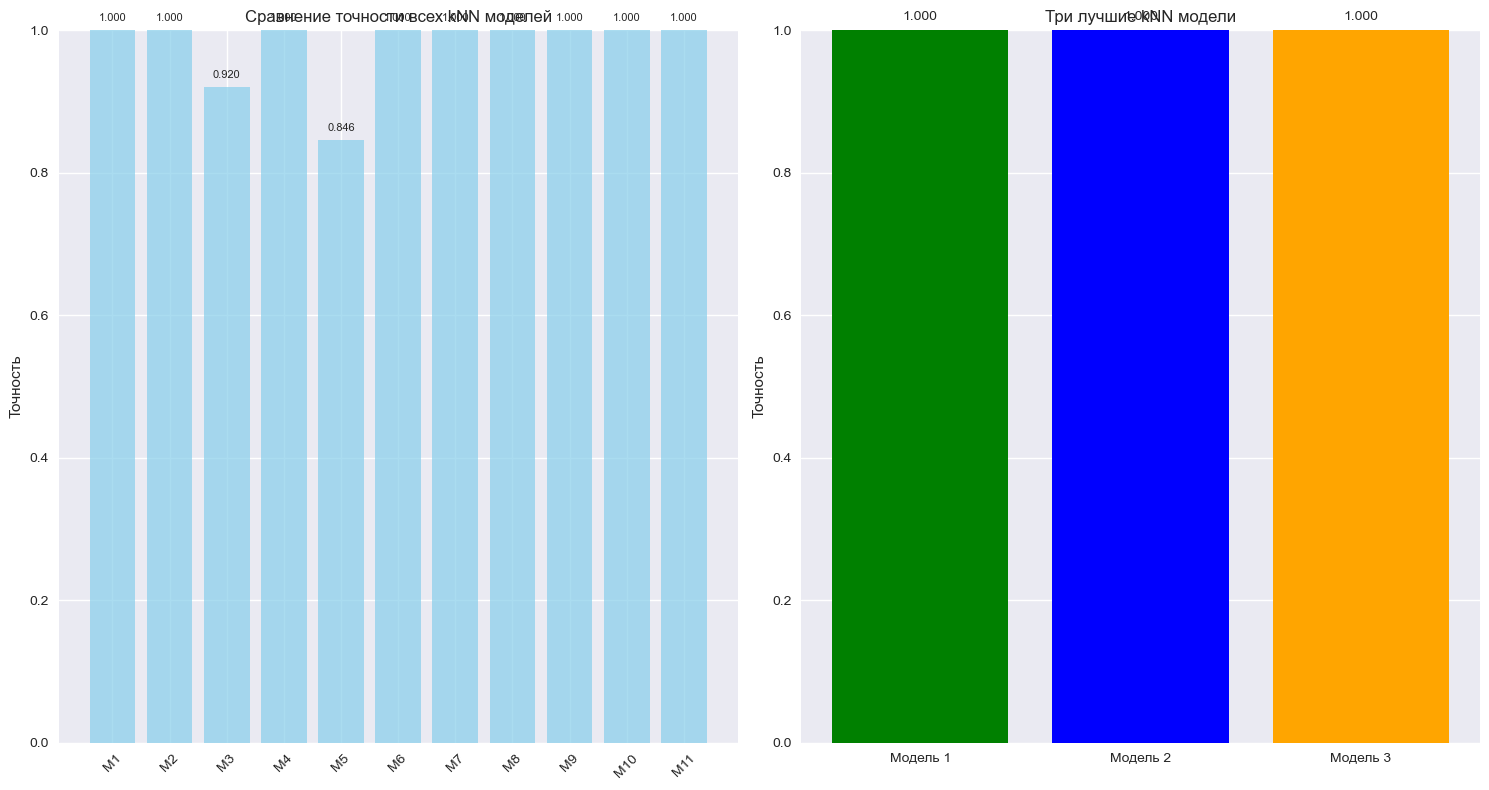


Графики для модели 1: test_size=0.2, metric=euclidean, weights=uniform, n_neighbors=5


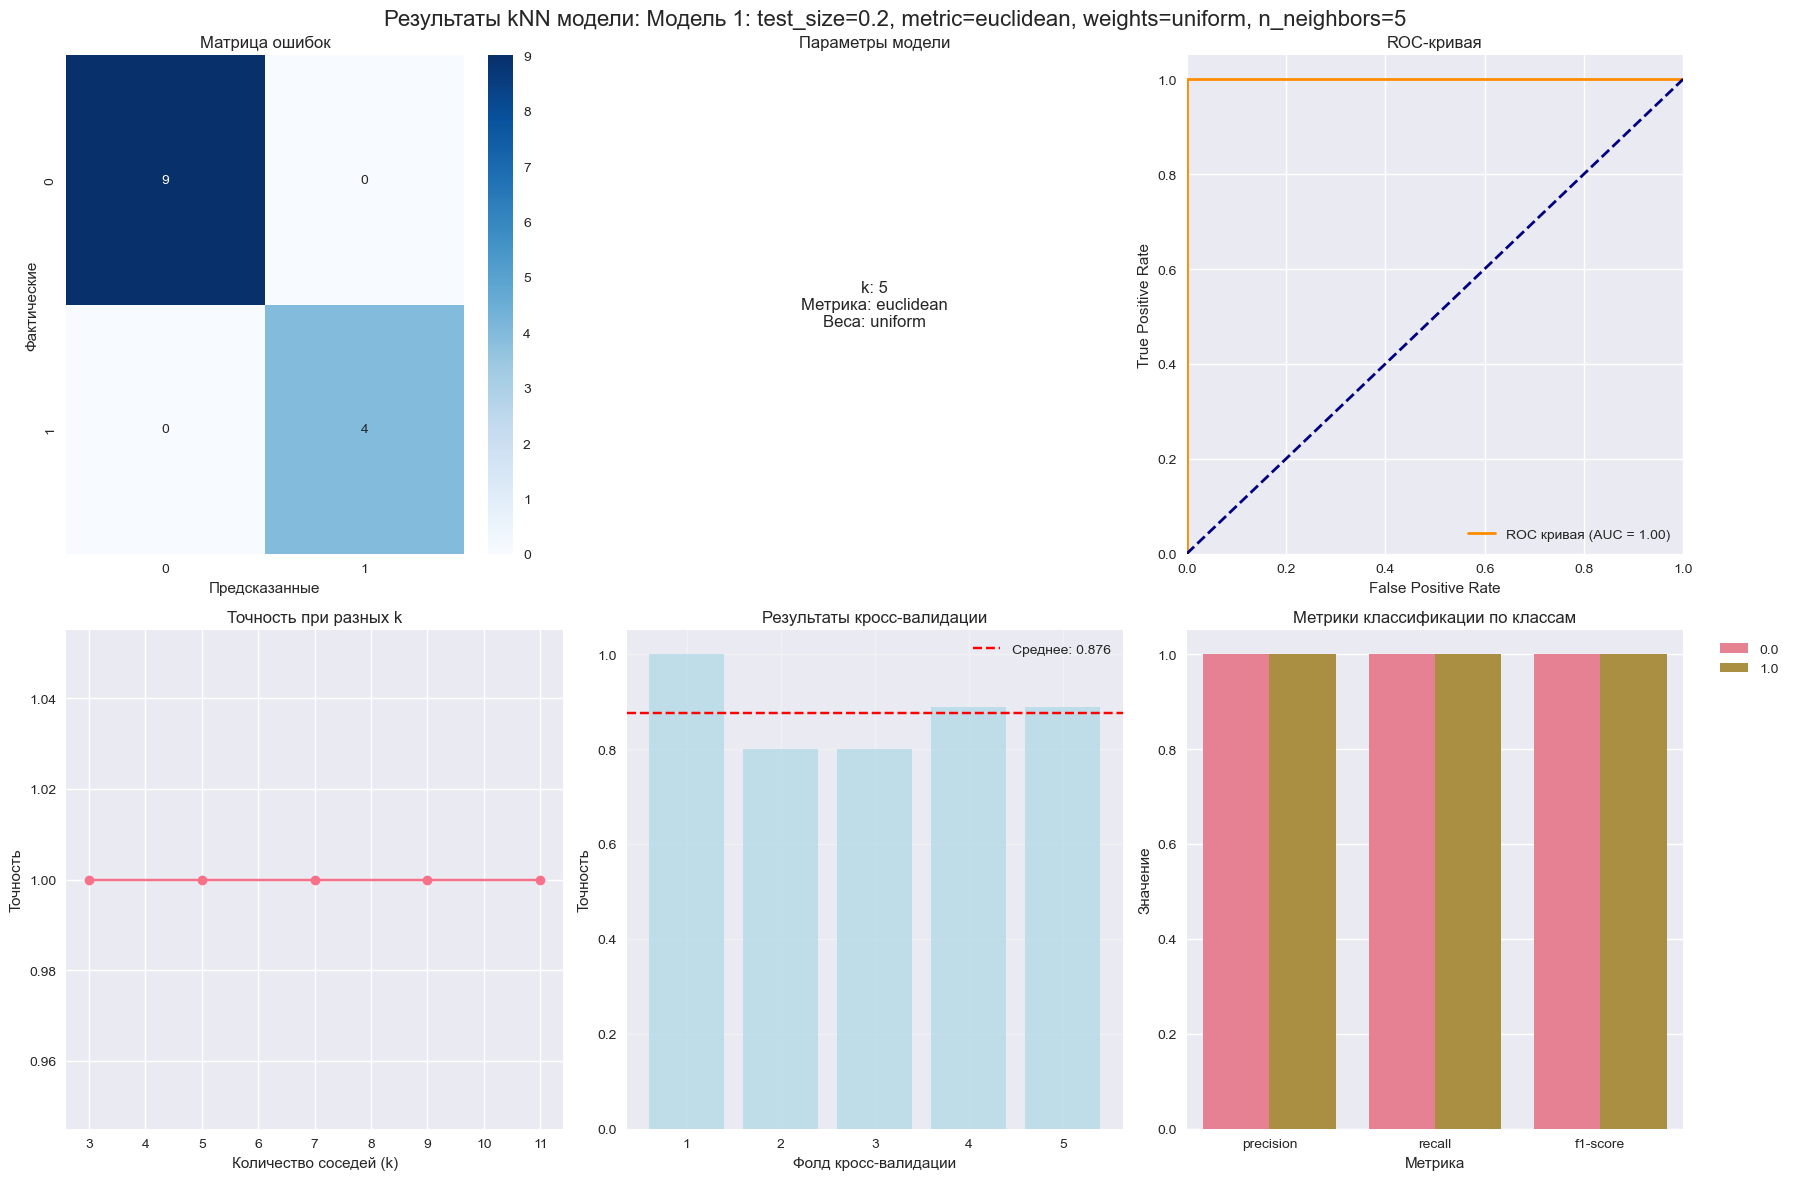


Графики для модели 2: test_size=0.3, metric=euclidean, weights=uniform, n_neighbors=5


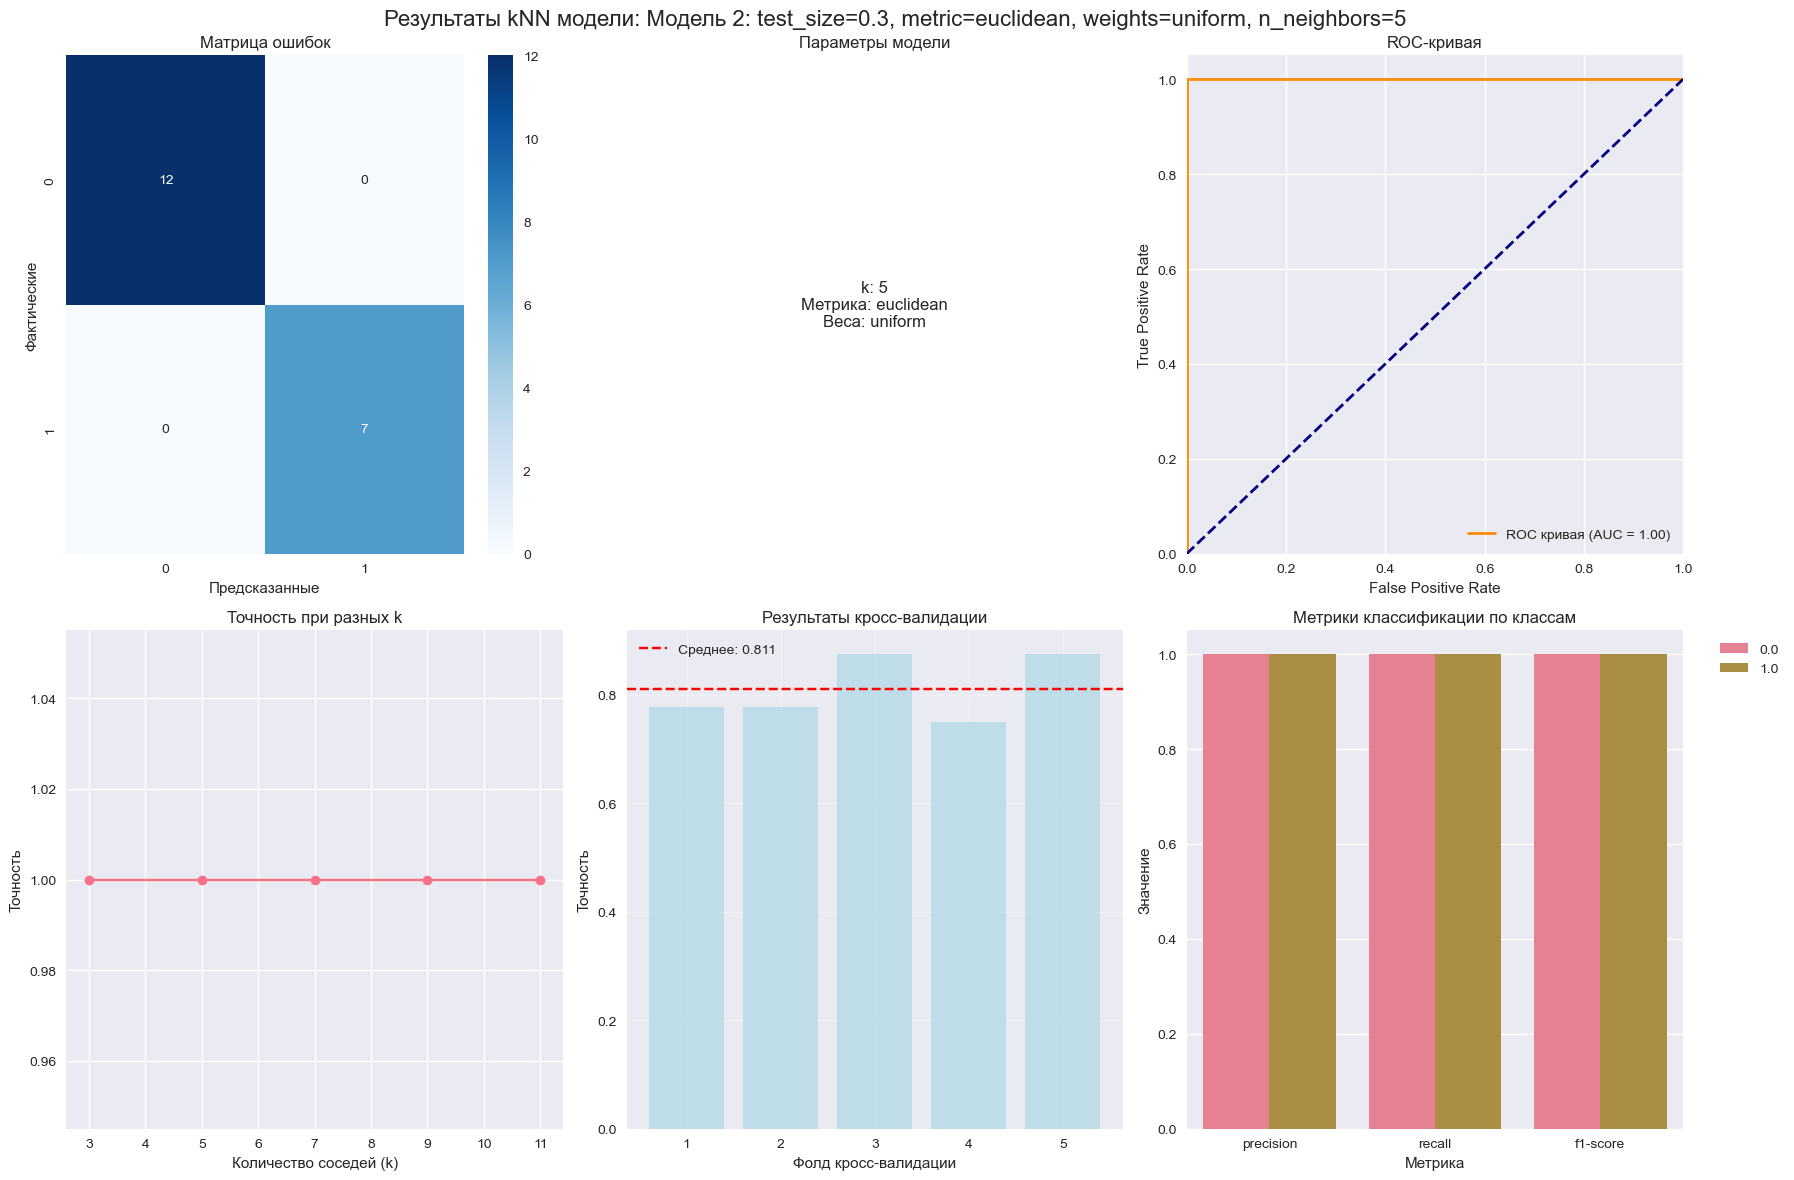


Графики для модели 3: test_size=0.2, metric=manhattan, weights=uniform, n_neighbors=5


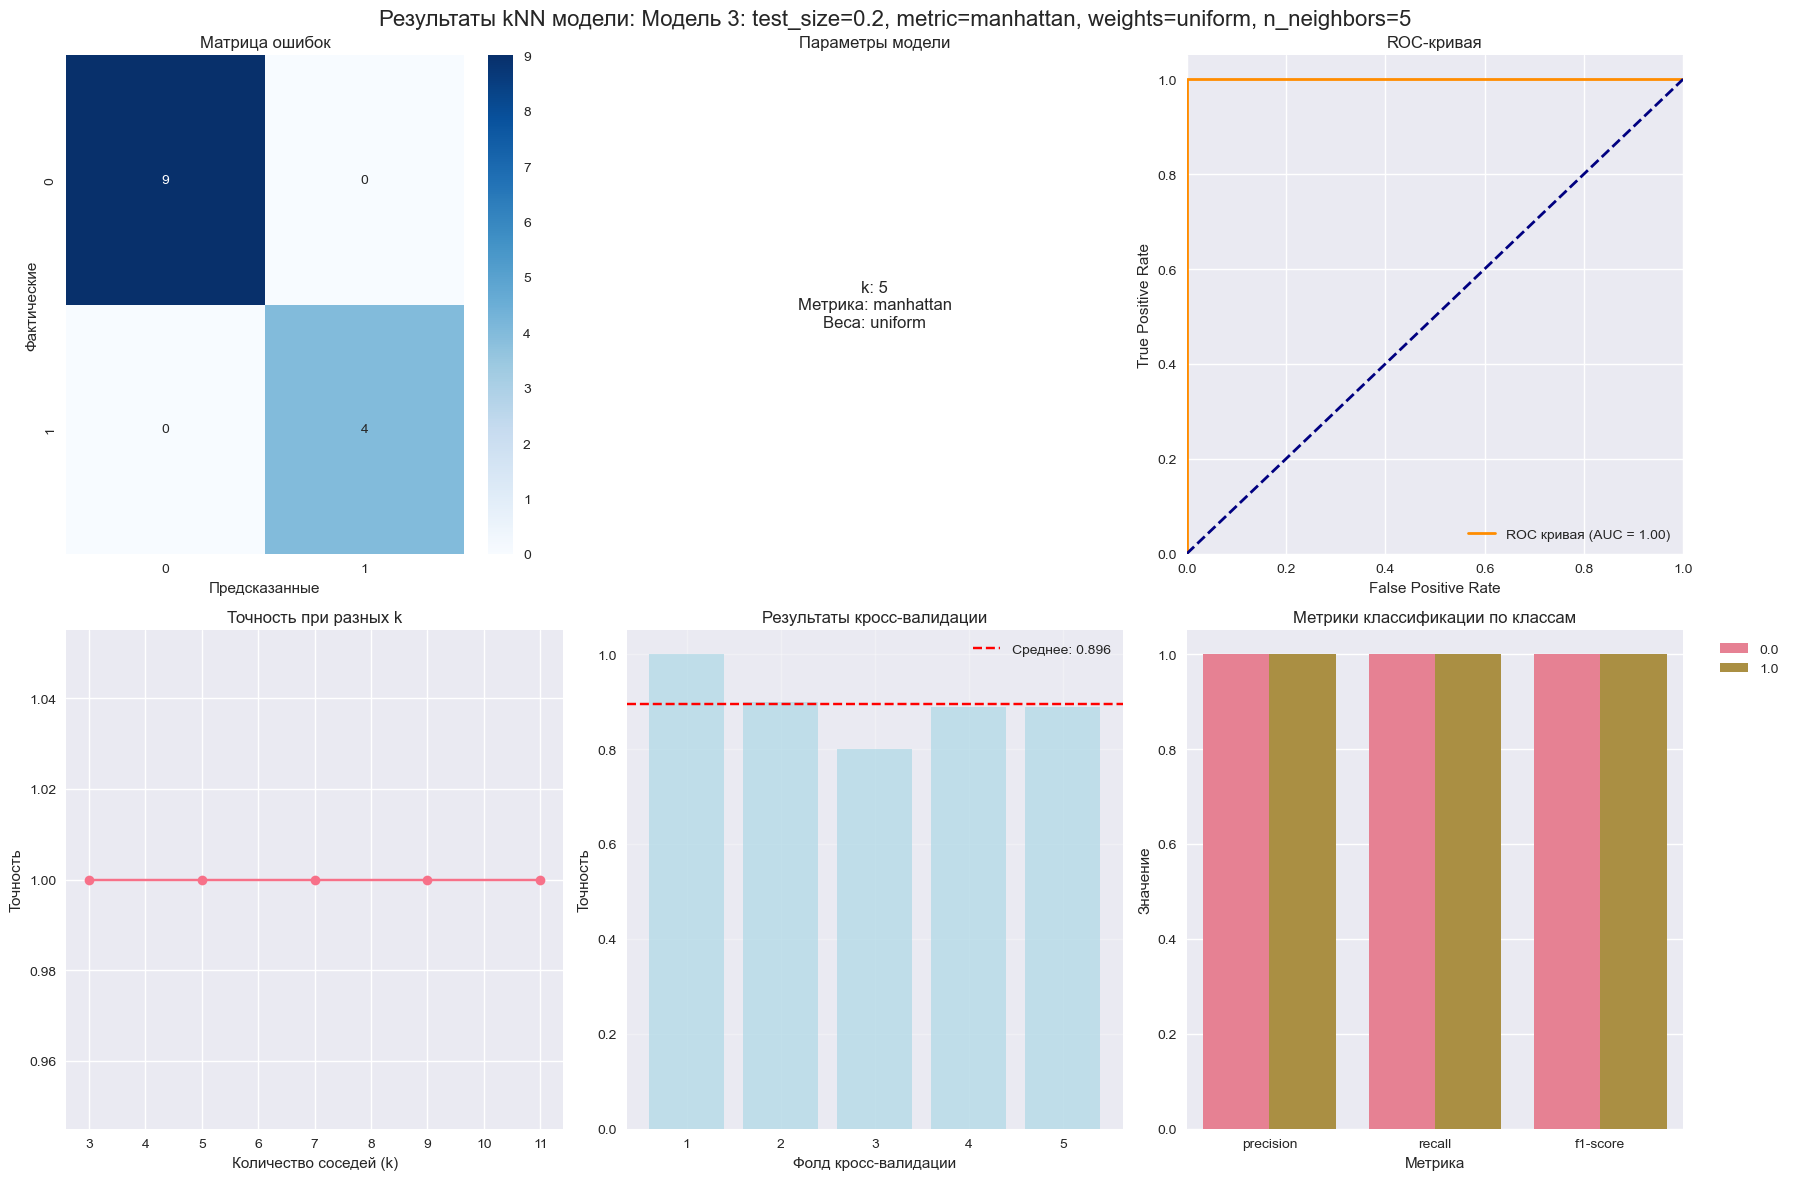

In [23]:
# Запуск эксперимента
if __name__ == "__main__":
    results_df, best_models = run_knn_experiment()